# Model Machine Learning untuk Ulasan

Notebook ini mengerjakan saran penggunaan dataset ulasan dari Kaggle yang membutuhkan model:

| Saran Kaggle | Bagian | Status |
|---|---|---|
| Sentiment Analysis | 2 | Dikerjakan |
| Rating Prediction | 3 | Dikerjakan |
| Category Classification | 4 | Dikerjakan |
| Product Recommendation | 5 | Tidak bisa — datanya tidak memungkinkan |
| Train Indonesian language models | 5 | Di luar skala project |

Semua model di sini adalah **model dasar (baseline)**: TF-IDF + regresi logistik. Tujuannya bukan mengejar skor tertinggi, melainkan menjawab pertanyaan yang lebih penting — *seberapa jauh teks ulasan bisa memberi tahu kita sesuatu, dan di mana batasnya?*

Dua prinsip dipegang sepanjang notebook:

1. **Setiap model dibandingkan dengan tebakan paling sederhana.** Model yang tidak mengalahkan "selalu tebak jawaban terbanyak" tidak berguna, seberapa pun tinggi akurasinya.
2. **Data latih dan uji dipisah per produk**, bukan per ulasan. Alasannya dijelaskan di bagian 1.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             mean_absolute_error, precision_recall_curve,
                             precision_score, recall_score)
from sklearn.model_selection import GroupShuffleSplit, train_test_split

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src import clean_reviews, review_analysis
from src import plot_style as ps

ps.terapkan()
pd.set_option("display.max_colwidth", 90)

ulasan = clean_reviews.bersihkan()
X = ulasan["ulasan"].astype(str)
produk = ulasan["produk_id"]

[reviews] 40,607 ulasan bersih (0 dibuang karena kosong/rating tidak valid)
[reviews] porsi ulasan negatif: 2.3%


In [2]:
def pisah_per_produk(y, seed=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    return next(gss.split(X, y, groups=produk))


def pisah_acak(y, seed=42):
    return train_test_split(np.arange(len(X)), test_size=0.2, random_state=seed, stratify=y)


def latih(idx_latih, idx_uji, y, class_weight=None):
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    A = vec.fit_transform(X.iloc[idx_latih])
    B = vec.transform(X.iloc[idx_uji])
    model = LogisticRegression(max_iter=3000, class_weight=class_weight).fit(A, y.iloc[idx_latih])
    return model, vec, B


def matriks_kebingungan(y_asli, y_prediksi, label, judul, ax):
    cm = confusion_matrix(y_asli, y_prediksi, labels=label)
    persen = cm / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(persen, cmap=ps.CMAP_BIRU, vmin=0, vmax=100)
    ax.set_xticks(range(len(label)), label, rotation=30, ha="right")
    ax.set_yticks(range(len(label)), label)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Asli")
    ax.grid(False)
    for i in range(len(label)):
        for j in range(len(label)):
            ax.text(j, i, f"{persen[i, j]:.0f}%\n({cm[i, j]:,})", ha="center", va="center",
                    fontsize=8, color="white" if persen[i, j] > 55 else ps.INK)
    ax.set_title(judul)

## 1. Kenapa dipisah per produk

Satu produk bisa punya puluhan ulasan. Kalau ulasan dipisah secara acak, ulasan dari produk yang sama akan tersebar di data latih *dan* data uji. Model lalu bisa "menghafal" ciri khas produk tertentu — nama merek, istilah khusus — dan skornya di data uji terlihat bagus padahal model tidak benar-benar belajar memahami ulasan.

Seberapa besar risikonya di data ini:

In [3]:
per_produk = ulasan.groupby("produk_id").size()
print(f"Produk: {len(per_produk):,}  |  median ulasan per produk: {per_produk.median():.0f}  |  terbanyak: {per_produk.max():,}")

idx_l, idx_u = pisah_acak(ulasan["kategori"])
bocor = set(produk.iloc[idx_l]) & set(produk.iloc[idx_u])
print(f"Dengan pemisahan acak, {len(bocor):,} produk muncul di data latih dan uji sekaligus "
      f"({len(bocor) / produk.nunique():.0%} dari semua produk)")

Produk: 3,664  |  median ulasan per produk: 2  |  terbanyak: 1,312
Dengan pemisahan acak, 1,555 produk muncul di data latih dan uji sekaligus (42% dari semua produk)


Dengan pemisahan per produk, setiap produk hanya ada di salah satu sisi. Model diuji pada produk yang benar-benar belum pernah dilihatnya — situasi yang sama dengan saat model dipakai sungguhan. Dampak nyatanya pada skor diukur di bagian 4.

## 2. Klasifikasi sentimen

*Saran Kaggle: Classify customer sentiment based on review text and ratings.*

Label diambil dari rating: bintang 1-2 = **negatif**, bintang 3-5 = **bukan negatif**. Tantangan utamanya sudah terlihat di notebook 02: ulasan negatif hanya 2,3%.

### Jebakan akurasi

Tebakan paling sederhana — "semua ulasan bukan negatif" — sudah menghasilkan akurasi hampir 98%, padahal tidak menemukan satu pun ulasan negatif. Karena itu yang diukur adalah **precision, recall, dan F1 untuk kelas negatif**:

- **Recall**: dari semua ulasan yang benar-benar negatif, berapa persen yang tertangkap?
- **Precision**: dari semua yang ditebak negatif, berapa persen yang benar?

In [4]:
y_sent = ulasan["is_negatif"].astype(int)
idx_l, idx_u = pisah_per_produk(y_sent)
y_uji = y_sent.iloc[idx_u]

hasil = []
def catat(nama, prediksi):
    hasil.append({
        "pendekatan": nama,
        "akurasi": (prediksi == y_uji.values).mean(),
        "precision (negatif)": precision_score(y_uji, prediksi, zero_division=0),
        "recall (negatif)": recall_score(y_uji, prediksi),
        "F1 (negatif)": f1_score(y_uji, prediksi),
    })

catat("Baseline: selalu 'bukan negatif'", np.zeros(len(y_uji), dtype=int))

aturan = X.iloc[idx_u].apply(lambda t: len(review_analysis.tandai_tema(t)) > 0).astype(int).values
catat("Aturan kata kunci (notebook 02)", aturan)

model_biasa, vec_s, B = latih(idx_l, idx_u, y_sent)
catat("Model TF-IDF + regresi logistik", model_biasa.predict(B))

model_seimbang, vec_s, B = latih(idx_l, idx_u, y_sent, class_weight="balanced")
pred_seimbang = model_seimbang.predict(B)
catat("Model + bobot kelas seimbang", pred_seimbang)

print(f"Data uji: {len(y_uji):,} ulasan, {y_uji.sum()} di antaranya negatif")
pd.DataFrame(hasil).set_index("pendekatan").style.format("{:.1%}")

Data uji: 9,057 ulasan, 291 di antaranya negatif


,akurasi,precision (negatif),recall (negatif),F1 (negatif)
pendekatan,,,,
Baseline: selalu 'bukan negatif',96.8%,0.0%,0.0%,0.0%
Aturan kata kunci (notebook 02),61.7%,5.7%,70.8%,10.6%
Model TF-IDF + regresi logistik,97.0%,78.0%,11.0%,19.3%
Model + bobot kelas seimbang,94.5%,34.5%,80.4%,48.2%


Beberapa hal terbaca dari tabel ini:

- **Baseline** akurasinya tinggi tapi recall-nya nol — contoh sempurna kenapa akurasi menyesatkan untuk data tidak seimbang.
- **Aturan kata kunci** dari notebook 02 punya recall lumayan, tapi precision-nya rendah. Aturan itu dirancang untuk *mengelompokkan* keluhan pada ulasan yang sudah pasti negatif, bukan untuk *mendeteksi* ulasan negatif — kata seperti "lama" juga muncul di ulasan positif ("sudah lama langganan").
- **Model biasa** sangat berhati-hati: tebakan negatifnya cukup akurat, tapi hanya menangkap sedikit ulasan negatif. Model belajar bahwa menebak "bukan negatif" hampir selalu benar.
- **Bobot kelas seimbang** memaksa model memberi perhatian lebih pada kelas minoritas. Recall naik drastis, dengan precision yang turun. Hasilnya F1 terbaik.

### Memilih titik kerja

Model sebenarnya mengeluarkan *probabilitas*, dan batas 50% hanyalah pilihan bawaan. Menggeser batas itu menukar precision dengan recall:

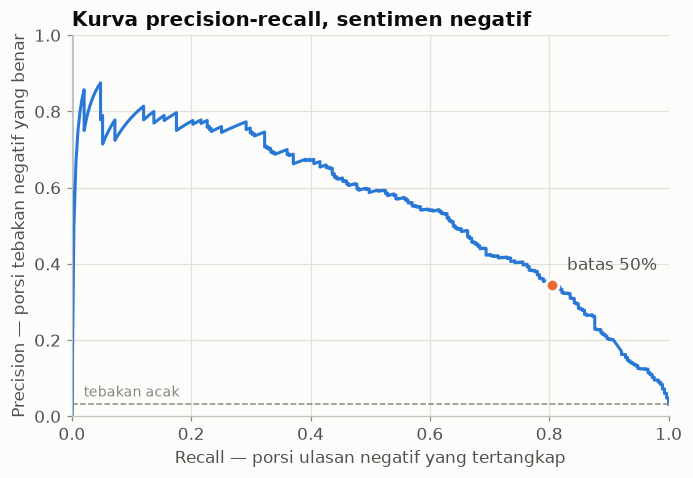

In [5]:
proba = model_seimbang.predict_proba(B)[:, 1]
precision, recall, ambang = precision_recall_curve(y_uji, proba)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color=ps.BIRU, linewidth=2)
i50 = np.argmin(np.abs(ambang - 0.5))
ax.scatter(recall[i50], precision[i50], s=70, color=ps.ORANYE, zorder=3,
           edgecolor=ps.SURFACE, linewidth=2)
ax.annotate("batas 50%", (recall[i50], precision[i50]), xytext=(10, 10),
            textcoords="offset points", color=ps.INK_2)
ax.axhline(y_uji.mean(), color=ps.MUTED, linestyle="--", linewidth=1)
ax.text(0.02, y_uji.mean() + 0.02, "tebakan acak", color=ps.MUTED, fontsize=9)
ax.set_xlabel("Recall — porsi ulasan negatif yang tertangkap")
ax.set_ylabel("Precision — porsi tebakan negatif yang benar")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(axis="y", visible=True)
ax.set_title("Kurva precision-recall, sentimen negatif")
plt.show()

Titik kerja yang tepat bergantung pada kegunaannya:

- Untuk **tim layanan pelanggan** yang ingin tidak ada keluhan terlewat, recall lebih penting — batasnya diturunkan, dan tim menerima lebih banyak peringatan palsu.
- Untuk **laporan otomatis** yang harus akurat, precision lebih penting — batasnya dinaikkan.

Kata-kata yang paling berpengaruh bagi model:

In [6]:
fitur = np.array(vec_s.get_feature_names_out())
bobot = model_seimbang.coef_[0]
pd.DataFrame({
    "paling mendorong ke NEGATIF": fitur[np.argsort(bobot)[::-1][:15]],
    "paling mendorong ke bukan negatif": fitur[np.argsort(bobot)[:15]],
})

,paling mendorong ke NEGATIF,paling mendorong ke bukan negatif
0,tidak,bagus
1,tidak sesuai,cepat
2,kecewa,mantap
3,kurang,oke
4,jelek,sesuai
5,rusak,baik
6,not,ok
7,dikirim,awet
8,tdk,terimakasih
9,gak,cepet


Model menemukan sendiri kata-kata yang juga ada di daftar aturan ("tidak sesuai", "kecewa", "rusak"), plus ejaan gaul yang tidak pernah didaftarkan secara manual ("tdk", "gak", "ga").

Sekarang ujian yang sebenarnya. Di notebook 02, tiga ulasan negatif ini **luput** dari aturan kata kunci. Bagaimana dengan model?

In [7]:
contoh_sulit = [
    "Beli 5 tdk bs dipakai semua",
    "warna nya ga sesuaii dengan yg saya ingin kan",
    "Beli 3. Cuma 1 yang bisa dipakai",
]
p = model_seimbang.predict_proba(vec_s.transform(contoh_sulit))[:, 1]
pd.DataFrame({
    "ulasan": contoh_sulit,
    "ditangkap aturan?": ["ya" if review_analysis.tandai_tema(t) else "tidak" for t in contoh_sulit],
    "probabilitas negatif (model)": [f"{v:.0%}" for v in p],
})

,ulasan,ditangkap aturan?,probabilitas negatif (model)
0,Beli 5 tdk bs dipakai semua,tidak,92%
1,warna nya ga sesuaii dengan yg saya ingin kan,tidak,90%
2,Beli 3. Cuma 1 yang bisa dipakai,tidak,92%


Inilah keunggulan model dibanding aturan: ia belajar dari pola kata yang *sebenarnya muncul* di ulasan negatif, termasuk ejaan yang tidak pernah terpikir untuk didaftarkan.

Tapi dua pendekatan ini tidak saling menggantikan. **Model mendeteksi** ulasan mana yang negatif; **aturan menjelaskan** keluhannya soal apa. Dashboard memakai aturan karena kebutuhannya adalah penjelasan yang bisa ditelusuri — setiap angka bisa dikembalikan ke kata pemicunya.

## 3. Prediksi rating 1-5

*Saran Kaggle: Predict customer ratings from review text.*

Pertanyaan yang lebih sulit: bisakah teks memberi tahu jumlah bintang *persisnya*?

In [8]:
y_rating = ulasan["rating"]
idx_l, idx_u = pisah_per_produk(y_rating)
y_uji = y_rating.iloc[idx_u]

hasil_rating = []
def catat_rating(nama, prediksi):
    hasil_rating.append({
        "pendekatan": nama,
        "rata-rata meleset (MAE, bintang)": mean_absolute_error(y_uji, prediksi),
        "macro-F1": f1_score(y_uji, prediksi, average="macro"),
        "akurasi": (prediksi == y_uji.values).mean(),
    })

catat_rating("Baseline: selalu bintang 5", np.full(len(y_uji), 5))
m, v, B = latih(idx_l, idx_u, y_rating)
catat_rating("Model biasa", m.predict(B))
m, v, B = latih(idx_l, idx_u, y_rating, class_weight="balanced")
pred_rating = m.predict(B)
catat_rating("Model + bobot kelas seimbang", pred_rating)

pd.DataFrame(hasil_rating).set_index("pendekatan").style.format("{:.3f}")

,"rata-rata meleset (MAE, bintang)",macro-F1,akurasi
pendekatan,,,
Baseline: selalu bintang 5,0.422,0.167,0.718
Model biasa,0.369,0.295,0.732
Model + bobot kelas seimbang,0.519,0.386,0.599


Hasilnya adalah pelajaran penting soal **pemilihan metrik**:

- **Model biasa** unggul tipis atas baseline di kedua metrik, tapi macro-F1-nya masih rendah — ia hampir selalu menebak bintang 4 atau 5, sehingga jarang menemukan ulasan bintang 1-2.
- **Model berbobot seimbang** punya macro-F1 tertinggi, karena lebih sering berani menebak bintang rendah. Tapi rata-rata melesetnya justru **paling buruk**, bahkan kalah dari tebakan "selalu bintang 5".

Jadi tidak ada model yang "terbaik" secara mutlak. Keduanya benar, karena menjawab pertanyaan yang berbeda. Kalau tujuannya menemukan ulasan bintang 1-2 yang langka, macro-F1 yang relevan. Kalau tujuannya memperkirakan rata-rata rating sebuah produk, "selalu 5" sulit dikalahkan justru karena rating memang menggelembung. **Metrik harus dipilih dari kebutuhan bisnis sebelum melatih model**, bukan dipilih sesudahnya berdasarkan mana yang angkanya paling bagus.

Di mana model salah menebak:

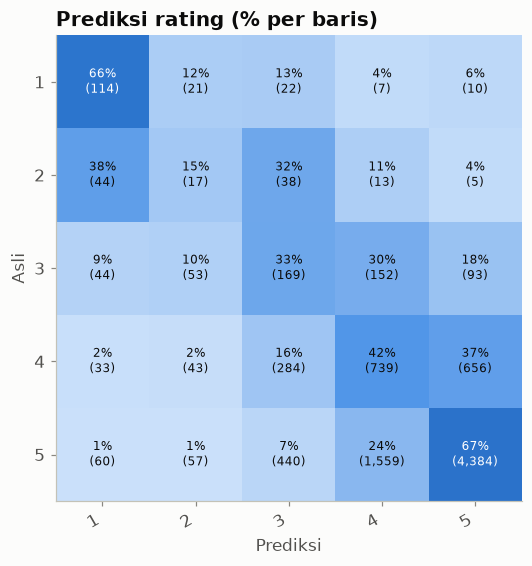

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
matriks_kebingungan(y_uji, pred_rating, [1, 2, 3, 4, 5], "Prediksi rating (% per baris)", ax)
plt.show()

Kesalahan terbesar ada di antara **bintang 3, 4, dan 5**. Ini bukan kelemahan modelnya, melainkan sifat datanya: ulasan bintang 4 dan 5 sering berbunyi sama ("barang bagus, pengiriman cepat"). Perbedaan antara 4 dan 5 bintang lebih banyak ditentukan kebiasaan pribadi pembeli daripada isi ulasannya. Tidak ada model — sesederhana ini atau secanggih apa pun — yang bisa membaca informasi yang memang tidak ada di teks.

Sebaliknya, **ujung-ujung skala** — bintang 1 dan bintang 5 — paling mudah dikenali, masing-masing sekitar dua pertiga tertebak benar. Yang paling sulit adalah **bintang 2**: bahasanya mirip bintang 1 ("kecewa") sekaligus bintang 3 ("lumayan, tapi..."), sehingga hanya sebagian kecil yang tertebak benar.

## 4. Klasifikasi kategori dari teks ulasan

*Saran Kaggle: Predict product categories from review text.*

Bagian ini sekaligus mengukur dampak kebocoran data yang dijelaskan di bagian 1:

In [10]:
y_kat = ulasan["kategori"]
urutan_kat = sorted(y_kat.unique())

hasil_kat = []
for nama, (idx_l, idx_u) in {
    "Pemisahan acak (bocor)": pisah_acak(y_kat),
    "Pemisahan per produk": pisah_per_produk(y_kat),
}.items():
    y_uji = y_kat.iloc[idx_u]
    m, v, B = latih(idx_l, idx_u, y_kat)
    pred = m.predict(B)
    terbanyak = y_kat.iloc[idx_l].mode()[0]
    hasil_kat.append({
        "pemisahan": nama,
        "akurasi baseline (selalu kategori terbanyak)": (y_uji == terbanyak).mean(),
        "akurasi model": (pred == y_uji.values).mean(),
        "macro-F1 model": f1_score(y_uji, pred, average="macro"),
    })
    if nama == "Pemisahan per produk":
        y_uji_kat, pred_kat, model_kat, vec_kat = y_uji, pred, m, v

pd.DataFrame(hasil_kat).set_index("pemisahan").style.format("{:.1%}")

,akurasi baseline (selalu kategori terbanyak),akurasi model,macro-F1 model
pemisahan,,,
Pemisahan acak (bocor),39.2%,50.3%,35.8%
Pemisahan per produk,36.8%,44.7%,31.2%


Dua temuan:

**Pertama, kebocoran data itu nyata.** Pemisahan acak memberi skor lebih tinggi daripada pemisahan per produk. Selisih itu bukan kemampuan model — itu model yang mengenali produk yang sudah pernah dilihatnya. Kalau hanya melaporkan hasil pemisahan acak, kita akan melebih-lebihkan kemampuan model.

**Kedua, modelnya lemah** — hanya sedikit di atas tebakan "selalu kategori terbanyak". Ini bukan kegagalan teknis, melainkan temuan tentang isi ulasan:

In [11]:
fitur = np.array(vec_kat.get_feature_names_out())
pd.DataFrame({
    k: fitur[np.argsort(model_kat.coef_[i])[::-1][:10]]
    for i, k in enumerate(model_kat.classes_)
})

,elektronik,fashion,handphone,olahraga,pertukangan
0,tinta,sepatunya,hp,bola,isi
1,berfungsi,sepatu,diterima dg,olahraga,isinya
2,tombol,jamnya,suara,matras,staples
3,laptop,jam,berfungsi,warung,dicoba
4,kabel,bata,holder,bolanya,kayu
5,mouse,ukuran,handphone,tebal,gun
6,stik,suka,siiiiiiiiiippppppppp,nyaman,tembak
7,kabelnya,size,patah,bahannya,kuat
8,test,jam nya,berguna,surabaya,staplesnya
9,baterai,diskon,suaranya,celana,krisbow


Kata-kata penanda tiap kategori sebagian besar masuk akal (sepatu, ukuran, baterai, matras). Beberapa lainnya adalah nama merek atau kota ("krisbow", "surabaya") — petunjuk yang hanya berlaku untuk toko tertentu dan tidak akan berlaku umum. Tapi masalah utamanya, **sebagian besar ulasan tidak membahas produknya sama sekali**. Ingat temuan notebook 02: yang paling sering ditulis adalah "sesuai deskripsi", "pengiriman cepat", dan "penjual responsif" — kalimat yang sama persis untuk sepatu maupun charger.

Temuan ini sendiri berguna bagi riset pasar: **ulasan Tokopedia lebih banyak menilai transaksinya daripada barangnya.**

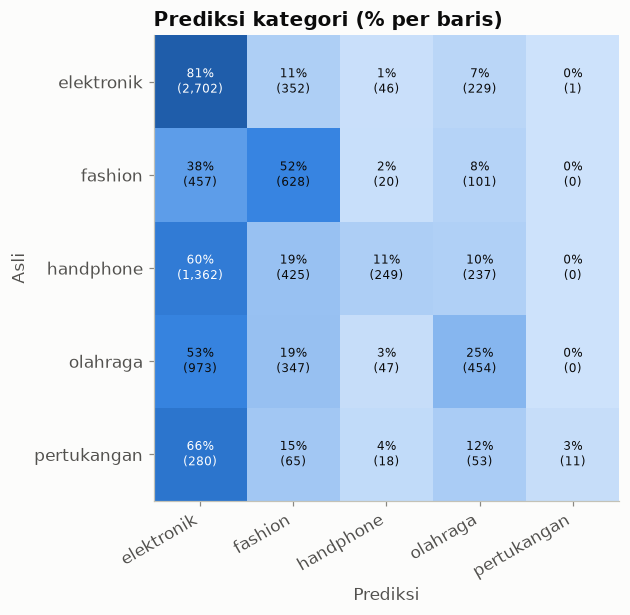

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
matriks_kebingungan(y_uji_kat, pred_kat, urutan_kat, "Prediksi kategori (% per baris)", ax)
plt.show()

Model cenderung menebak **elektronik** — kategori dengan ulasan terbanyak — untuk kasus yang ragu. Paling mencolok, sebagian besar ulasan **handphone** tertebak sebagai elektronik. Ini wajar: ulasan charger, kabel data, atau headset terbaca sama saja di kedua kategori, dan batas antara keduanya memang kabur. Pertukangan, dengan hanya 60 produk, hampir tidak pernah tertebak benar.

## 5. Yang tidak dikerjakan, dan alasannya

**Product Recommendation.** Sistem rekomendasi yang umum (*collaborative filtering*) membutuhkan data *siapa membeli atau menilai apa*. Dataset ini **tidak memuat identitas pengulas sama sekali**, sehingga tidak ada cara mengetahui bahwa dua ulasan berasal dari orang yang sama. Yang bisa dilakukan hanyalah analisis preferensi per kategori — dan itu sudah dikerjakan di notebook 02, bagian 3.

**Melatih language model Bahasa Indonesia.** Melatih model bahasa dari nol butuh jutaan hingga miliaran kalimat dan GPU. Dengan 40 ribu ulasan pendek, itu tidak masuk akal. Langkah lanjutan yang realistis adalah kebalikannya: memakai model yang sudah dilatih, seperti **IndoBERT**, lalu *fine-tuning* untuk klasifikasi sentimen. Model seperti itu memahami konteks kalimat, sehingga berpotensi menangkap keluhan tidak langsung seperti "cuma 1 yang bisa dipakai" dengan lebih andal.

## Ringkasan

| Tugas | Hasil | Pelajaran |
|---|---|---|
| Sentimen negatif | Model berbobot seimbang menangkap sebagian besar ulasan negatif, dengan banyak peringatan palsu | Akurasi menyesatkan untuk data tidak seimbang; titik kerja dipilih sesuai kegunaan |
| Rating 1-5 | Model biasa unggul tipis di kedua metrik; bobot seimbang menukar MAE demi macro-F1 | Metrik dipilih dari kebutuhan bisnis, bukan dari angka yang paling bagus |
| Kategori dari teks | Hanya sedikit di atas baseline | Ulasan membahas transaksi, bukan produk |
| Pemisahan data | Pemisahan acak menaikkan skor secara semu | Uji model pada produk yang belum pernah dilihatnya |

Pesan utamanya: model yang jujur dievaluasi sering terlihat kurang mengesankan daripada model yang dievaluasi sembarangan — tapi hanya yang pertama yang bisa dipercaya saat dipakai.